Dataset loaded successfully. Initial shape: (120, 5)
Rohith John 24BAD100

Training base models...
Training Stacking Classifier...

--- Model Accuracies ---
Logistic Regression: 83.33%
SVM:                 83.33%
Decision Tree:       95.83%
Stacking Classifier: 95.83%


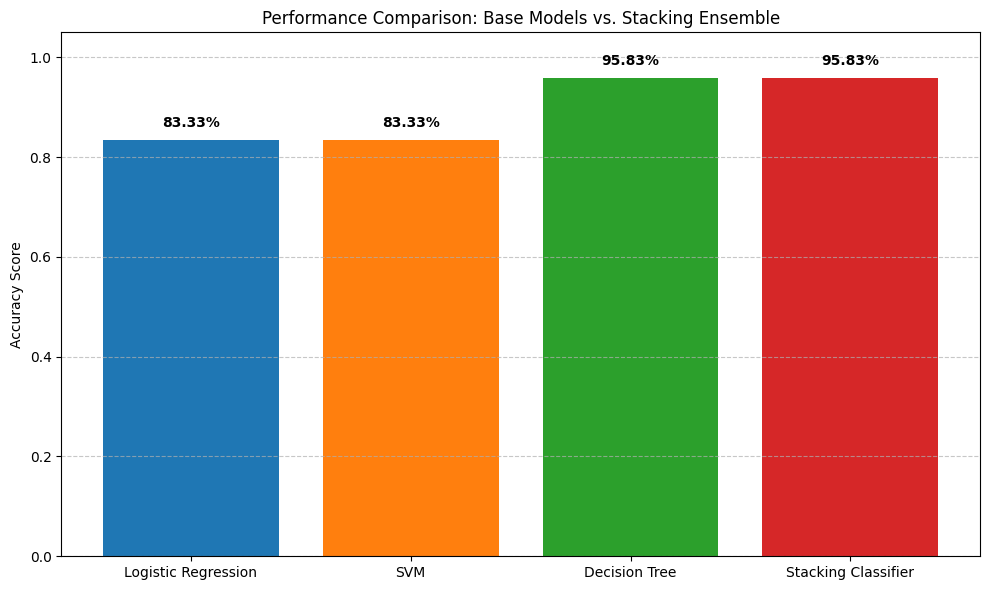

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset
# REMINDER: Ensure 'heart_stacking.csv' is uploaded to your Colab session storage.
try:
    df = pd.read_csv('heart_stacking.csv')
    print(f"Dataset loaded successfully. Initial shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'heart_stacking.csv' not found. Please upload it to Colab.")
    raise
print("Rohith John 24BAD100")
# --- Robust Data Preprocessing ---
# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Automatically identify the target column
# (Common names: 'target', 'HeartDisease', 'num', or similar)
possible_targets = ['target', 'heartdisease', 'num', 'presence', 'outcome', 'disease']
target_col = None

for col in df.columns:
    if col.lower() in possible_targets:
        target_col = col
        break

# If a standard name isn't found, assume the last column is the target
if target_col is None:
    target_col = df.columns[-1]
    print(f"Note: Assuming the last column '{target_col}' is the target variable.")

# One-hot encode any categorical text features just in case
df = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target variable (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Base Models
print("\nTraining base models...")

# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled))

# Support Vector Machine (SVM)
# Note: probability=True is often helpful if the meta-model needs prediction probabilities
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_acc = accuracy_score(y_test, dt_model.predict(X_test_scaled))

# 3. Combine using StackingClassifier
print("Training Stacking Classifier...")
# Define the base models for the stack
base_estimators = [
    ('lr', LogisticRegression(random_state=42)),
    ('svm', SVC(kernel='linear', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# The final_estimator uses the predictions of the base estimators to make the final call
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5 # 5-fold cross-validation during training to prevent overfitting
)

stacking_model.fit(X_train_scaled, y_train)
stacking_acc = accuracy_score(y_test, stacking_model.predict(X_test_scaled))

# 4. Compare with individual models
print("\n--- Model Accuracies ---")
print(f"Logistic Regression: {lr_acc * 100:.2f}%")
print(f"SVM:                 {svm_acc * 100:.2f}%")
print(f"Decision Tree:       {dt_acc * 100:.2f}%")
print(f"Stacking Classifier: {stacking_acc * 100:.2f}%")

# ----------------- Visualizations -----------------

plt.figure(figsize=(10, 6))

models = ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking Classifier']
accuracies = [lr_acc, svm_acc, dt_acc, stacking_acc]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(models, accuracies, color=colors)
plt.ylim(0, 1.05) # Give a little headroom above 100%
plt.ylabel('Accuracy Score')
plt.title('Performance Comparison: Base Models vs. Stacking Ensemble')

# Add the exact percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f"{yval*100:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()